In [3]:
import grewpy
from grewpy import Corpus, CorpusDraft, Request
from collections import Counter
import pandas as pd

import sys
sys.path.insert(1, "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/tod")

import tod.corpus
import tod.outliers
import tod.clustering
import tod.plotting
import tod.dimension_reduction_classic

GREW_PATTERN = "pattern{X[upos<>PUNCT]}"
PATTERNS_TEXT_FILE = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/3. probability_matrix/patterns_all_nodes.txt"

connected to port: 50027


In [2]:
def treebank_to_corpus(treebank_path):
    corpus = tod.corpus.Corpus(
    treebank_path=treebank_path,
    grew_pattern=GREW_PATTERN,
    patterns_text_file=PATTERNS_TEXT_FILE,
    use_sud=True,
    matrix_type="coverage",
    # excluded_feature_patterns=[r"CxnElt=", r"Cxn=", r"own", r"Gender"]
        # excluded_feature_patterns=[r"CxnElt=", r"Cxn=", r"XML=", r"PDTB=", r"SplitAnte=", r"MSeg=", r"Entity=", r"Discourse=", r"Bridge=", r"own", r"Degree=Pos"]
    excluded_feature_patterns=[r"own"],
    included_feature_patterns=[r"upos=", 
                                r"position=", 
                                r"rel_shallow=",
                                r"Aspect=",  
                                r"Animacy=",  
                                r"Case=",  
                                r"Clusivity=",  
                                r"Definite=",  
                                r"Deixis=", 
                                r"DeixisRef",  
                                r"Evident=",  
                                r"Negation=",
                                r"Number=",  
                                r"Gender=",  
                                r"Degree=",  
                                r"ExtPos=", 
                                r"Foreign=", 
                                r"Mood",  
                                r"NounClass=",  
                                r"NumType=",  
                                r"Person=",  
                                r"Polarity=", 
                                r"Polite=",  
                                r"Poss=",  
                                r"PronType=",  
                                r"Reflex=",  
                                r"Tense=",      
                                r"VerbForm=",  
                                r"Voice=",   ])
    return corpus

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def make_stability_plot(transition_matrix, language):
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        transition_matrix, 
        annot=True,      # Show the numbers in the cells
        cmap="YlOrRd",   # Color gradient: Yellow (low) to Red (high)
        fmt=".2f"        # Format to 2 decimal places
    )

    plt.title(f"Stability Matrix - UD_{language}")
    plt.ylabel("Original Category (from Treebank)")
    plt.xlabel("Rival Category (The 'Intruder')")
    plt.savefig(f"/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/29. polycategoriality/stability_intruder_plots/UD_{language}_stability_plot.png", dpi=300, bbox_inches='tight')
    plt.close()

In [5]:
import numpy as np

def calculate_weighted_stability(transition_matrix, category_counts):
    """
    Calculates the Weighted Average Stability of a language.
    
    Args:
        transition_matrix (pd.DataFrame): The full overlap matrix (rows sum to 1).
        category_counts (dict/Series): The frequency of each category (e.g., token counts).
    
    Returns:
        float: The WAS score (0.0 to 1.0).
    """
    # 1. Get the diagonal (Stability of each category)
    # np.diag extracts the diagonal; we match it with index to ensure alignment
    categories = transition_matrix.index
    stability_scores = pd.Series(np.diag(transition_matrix), index=categories)
    
    # 2. Align the counts with the categories present in the matrix
    weights = pd.Series(category_counts).reindex(categories).fillna(0)
    
    # 3. Calculate Weighted Average
    total_weight = weights.sum()
    if total_weight == 0: return 0
    
    weighted_stability = (stability_scores * weights).sum() / total_weight
    
    return weighted_stability

In [6]:
import pandas as pd
import numpy as np
from collections import Counter

def make_stability_matrix(corpus, similarity_matrix, language):
    all_lex_units = list(corpus._idx2lexunit.items())
    all_categories = [lu[1] for idx, lu in all_lex_units]
    category_counts = Counter(all_categories)
    total_count = len(all_categories)
    category_freqs = {cat: count / total_count for cat, count in category_counts.items()}
    
    all_data_full = []
    
    # OPTIMIZATION: Process using vectorized numpy where possible
    for idx, (lex_idx, lex_unit) in enumerate(all_lex_units):
        current_cat = lex_unit[1]
        sim_row = similarity_matrix[lex_idx]
        
        # Only look at neighbors with sim > 0.7
        # We use a mask to avoid sorting the whole row
        mask = sim_row > 0.7
        mask[lex_idx] = False # Don't compare to self
        
        eligible_indices = np.where(mask)[0]
        if len(eligible_indices) == 0:
            continue
            
        # Get top 20 efficiently
        if len(eligible_indices) > 20:
            # Get the actual similarity values for eligible neighbors
            eligible_sims = sim_row[eligible_indices]
            # Find the indices of the top 20 within the eligible list
            top_k_local_idx = np.argpartition(eligible_sims, -20)[-20:]
            closest_neighbours = eligible_indices[top_k_local_idx]
        else:
            closest_neighbours = eligible_indices

        # 1. Calculate weighted categorical counts
        raw_weights = {}
        total_raw_weight = 0
        for n_idx in closest_neighbours:
            n_cat = corpus._idx2lexunit[n_idx][1]
            sim = sim_row[n_idx]
            raw_weights[n_cat] = raw_weights.get(n_cat, 0) + sim
            total_raw_weight += sim

        # 2. Normalize and Re-normalize
        norm_probs = {}
        for cat, weight in raw_weights.items():
            # Divide relative weight by global frequency (P_norm)
            norm_probs[cat] = (weight / total_raw_weight) / category_freqs[cat]
        
        sum_norm = sum(norm_probs.values())
        for cat, prob in norm_probs.items():
            all_data_full.append({
                "Original": current_cat, 
                "Neighbour": cat, 
                "Weight": prob / sum_norm
            })
        
    # --- Matrix Construction ---
    df = pd.DataFrame(all_data_full)
    exclude = {"X", "SYM"} 
    unique_cats = set(df['Original']).union(set(df['Neighbour']))
    clean_categories = sorted([c for c in unique_cats if c not in exclude])

    matrix = df.groupby(['Original', 'Neighbour'])['Weight'].sum().unstack(fill_value=0)
    matrix = matrix.reindex(index=clean_categories, columns=clean_categories, fill_value=0)

    # Row Normalization
    row_sums = matrix.sum(axis=1)
    full_transition_matrix = matrix.div(row_sums.replace(0, 1), axis=0)

    # Plotting
    make_stability_plot(full_transition_matrix, language)

    # Final Score
    return calculate_weighted_stability(full_transition_matrix, category_freqs)

In [7]:
from sklearn.metrics.pairwise import cosine_similarity
LANG_TO_INCLUDE = [
    "Gheg", "Bulgarian", "Belarusian", "Russian", "Ukrainian", "Polish", "Slovak",
    "Czech", "Slovenian", "Croatian", "Serbian", "UpperSorbian", "German", "Dutch", "Afrikaans", "English",
    "Norwegian", "Swedish", "Danish", "Icelandic", "Faroese", "Romanian", "Pomak", "Breton", "Greek", "Catalan", "Spanish",
    "Portuguese", "Italian", "French", "Galician", "Maltese", "Hebrew", "Welsh", "Irish", "ScottishGaelic", "Manx", "Kurmanji",
    "Persian", "Arabic", "Javanese", "Indonesian", "Vietnamese", "Thai", "Urdu", "Hindi", "Japanese", "Xibe", "Uyghur", "Kazakh", "Turkish",
    "Buryat", "Tamil", "Basque", "Korean", "Hungarian", "NorthSami", "Finnish", "Estonian", "Lithuanian", "Latvian", "Armenian", "WesternArmenian", 
    "Erzya", "KomiZyrian", "Chinese", "Cantonese"
]

def process_treebank(treebank_path):
    language = treebank_path.split("_")[1:][-1]
    lang_to_test = language.split("-")[0]
    # if lang_to_test not in LANG_TO_INCLUDE:
    #     print(f"Skipping {language} as it's not in the inclusion list.")
    #     return None, lang_to_test
    corpus = treebank_to_corpus(treebank_path)
    similarity_matrix = cosine_similarity(corpus.feature_matrix)
    was_score = make_stability_matrix(corpus, similarity_matrix, language)
    return was_score, language
    

In [9]:
from tqdm.auto import tqdm
import os

# treebanks_folder = "/Users/madalina/Documents/PHD/code/data/small_test"
# treebanks_folder = "/Users/madalina/Documents/PHD/code/data/single_treebank"
treebanks_folder = "/Users/madalina/Documents/PHD/code/data/test"
treebanks = [t for t in os.listdir(treebanks_folder) if t.startswith("UD_")]
stability_scores = {}
for treebank in tqdm(treebanks, desc="Processing treebanks"):
    print(f"Processing {treebank}...")
    full_path = os.path.join(treebanks_folder, treebank)
    # was_score, language = process_treebank(full_path)
    try:
        was_score, language = process_treebank(full_path)
        stability_scores[language] = was_score
    except Exception as e:
        print(f"Error processing {treebank}: {e}")
    with open(f"/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/29. polycategoriality/stability_intruder_plots/stability_scores.txt", "w") as f:
        for lang, score in stability_scores.items():
            f.write(f"{lang}: {score}\n")

Processing treebanks:   0%|          | 0/182 [00:00<?, ?it/s]

Processing UD_Akkadian-RIAO...
Processing UD_Central_Kurdish-Mukri...
Processing UD_Armenian-ArmTDP...
Processing UD_Welsh-CCG...
Processing UD_Gheg-GPS...
Processing UD_Old_East_Slavic-TOROT...
Processing UD_Tswana-Popapolelo...
Processing UD_Classical_Armenian-CAVaL...
Processing UD_Azerbaijani-TueCL...
Processing UD_Guajajara-TuDeT...
Processing UD_Nenets-Tundra...
Processing UD_Khoekhoe-KDT...
Processing UD_Bavarian-MaiBaam...
Processing UD_Indonesian-GSD...
Processing UD_Ukrainian-IU...
Processing UD_Dutch-LassySmall...
Processing UD_Egyptian-UJaen...
Processing UD_Polish-PDB...
Processing UD_Kazakh-KTB...
Processing UD_Chintang-CTNTB...
Processing UD_Latin-ITTB...
Processing UD_Madi-Jarawara...
Error processing UD_Madi-Jarawara: 'Original'
Processing UD_Buryat-BDT...
Processing UD_Kaapor-TuDeT...
Error processing UD_Kaapor-TuDeT: 'Original'
Processing UD_Bokota-ChibErgIS...
Processing UD_Estonian-EDT...
Processing UD_Croatian-SET...
Processing UD_Gothic-PROIEL...
Processing UD_Ol

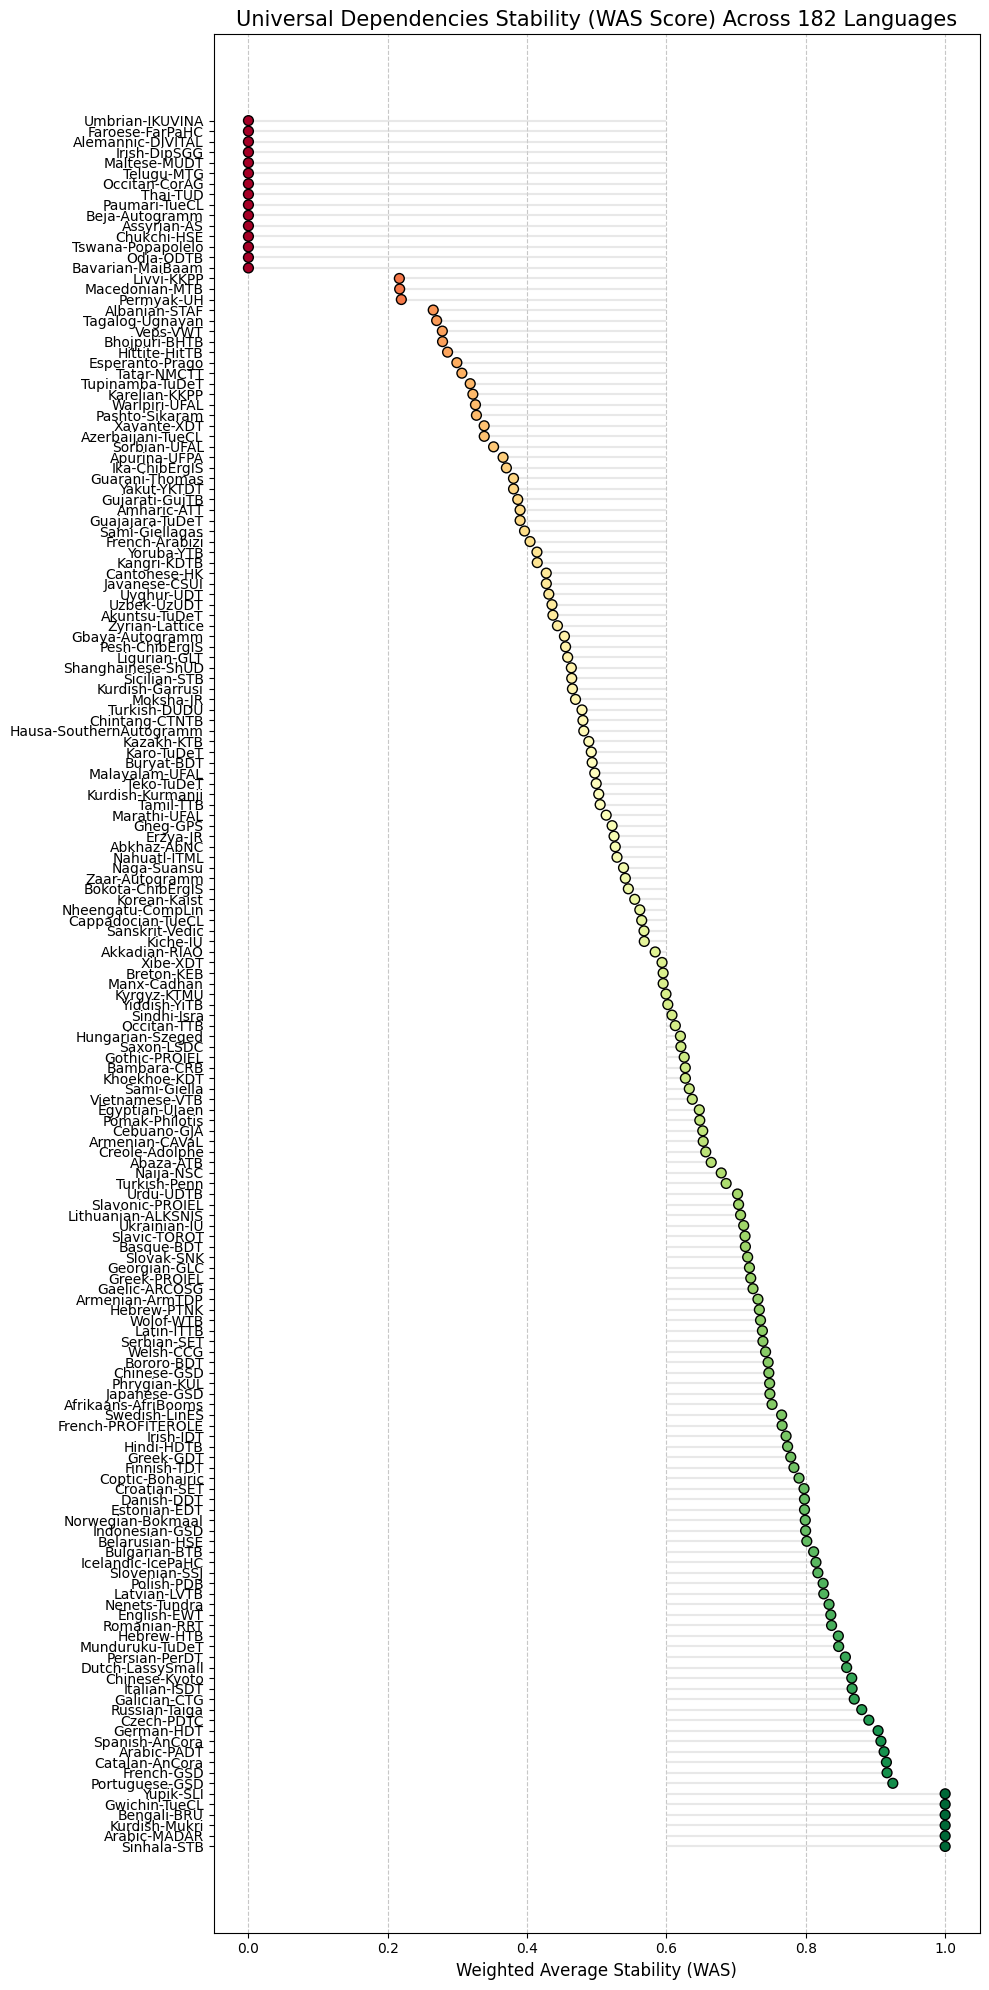

In [16]:
df_results = pd.DataFrame(list(stability_scores.items()), columns=['Language', 'WAS'])
df_results = df_results.sort_values(by='WAS', ascending=False)

plt.figure(figsize=(10, 20)) # Tall and thin to accommodate 100 labels

# Use a color palette to highlight the spectrum
norm = plt.Normalize(df_results['WAS'].min(), df_results['WAS'].max())
colors = plt.cm.RdYlGn(norm(df_results['WAS'])) # Red (low) to Green (high)

plt.hlines(y=df_results['Language'], xmin=0.6, xmax=df_results['WAS'], color='lightgrey', alpha=0.5)
plt.scatter(df_results['WAS'], df_results['Language'], color=colors, s=50, edgecolors='black', zorder=3)

plt.title("Universal Dependencies Stability (WAS Score) Across 182 Languages", fontsize=15)
plt.xlabel("Weighted Average Stability (WAS)", fontsize=12)
# plt.ylabel("Language / Treebank", fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
df_results.to_csv("/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/29. polycategoriality/stability_intruder_plots/stability_scores.csv", index=False)

In [7]:
df_results = pd.read_csv("/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/29. polycategoriality/stability_intruder_plots/stability_scores.csv")

In [8]:
LANG_TO_INCLUDE = [
    "Gheg-GPS", "Bulgarian-BTB", "Belarusian-HSE", "Russian-Taiga", "Ukrainian-IU", "Polish-PDB", "Slovak-SNK",
    "Czech-PDTC", "Slovenian-SSJ", "Croatian-SET", "Serbian-SET", "Sorbian-UFAL", "German-HDT", "Dutch-LassySmall", "Afrikaans-AfriBooms", "English-EWT",
    "Norwegian-Bokmaal", "Swedish-LinES", "Danish-DDT", "Icelandic-IcePaHC", "Romanian-RRT", "Pomak-Philotis", "Breton-KEB", "Greek-GDT", "Catalan-AnCora", "Spanish-AnCora",
    "Portuguese-GSD", "Italian-ISDT", "French-GSD", "Galician-CTG", "Hebrew-HTB", "Welsh-CCG", "Irish-IDT", "Gaelic-ARCOSG", "Manx-Cadhan", "Kurdish-Kurmanji",
    "Persian-PerDT", "Arabic-PADT", "Javanese-CSUI", "Indonesian-GSD", "Vietnamese-VTB", "Urdu-UDTB", "Hindi-HDTB", "Japanese-GSD", "Xibe-XDT", "Uyghur-UDT", "Kazakh-KTB", "Turkish-Penn",
    "Tamil-TTB", "Basque-BDT", "Korean-GSD", "Hungarian-Szeged", "Sami-Giella", "Finnish-TDT", "Estonian-EDT", "Lithuanian-ALKSNIS", "Latvian-LVTB", "Armenian-ArmTDP" 
    "Erzya-JR", "Zyrian-Lattice", "Chinese-GSD", "Cantonese-HK"
]

df_results = df_results[df_results['Language'].isin(LANG_TO_INCLUDE)]

In [9]:
LANGS_TO_EXCLUDE = [
    "Central_Kurdish-Mukri", "Tswana-Popapolelo", "Azerbaijani-TueCL", "Madi-Jarawara", 
    "Kaapor-TuDeT", "Assyrian-AS", "Yupik-SLI", "Warlpiri-UFAL", "Old_Irish-DipSGG", 
    "Apurina-UFPA", "Sinhala-STB", "Komi_Permyak-UH", "Malayalam-UFAL", "Bengali-BRU", 
    "Neapolitan-RB", "Naga-Suansu", "Skolt_Sami-Giellagas", "Abaza-ATB", 
    "Macedonian-MTB", "Tagalog-Ugnayan", "Turkish", "Arabic-MADAR", "Kurdish-Mukri", "Sinhala-STB", "Bengali-BRU", "Gwichin-TueCL", "Irish-DipSGG",
    "Tswana-Popapolelo", "Macedonian-MTB", "Permyak-UH", "Cebuano-GJA", "Hittite-HitTB", "Munduruku-TuDeT", "Nenets-Tundra", "Alemannic-DIVITAL", "Maltese-MUDT", "Occitan-CorAG",
    "Telugu-MTG", "Thai-TUD", "Faroese-FarPaHC", "Paumari-TueCL", "Chukchi-HSE", "Odia-ODTB", "Bavarian-MaiBaam", "Umbrian-IKUVINA"
]

df_results.drop(df_results[df_results['Language'].isin(LANGS_TO_EXCLUDE)].index, inplace=True)

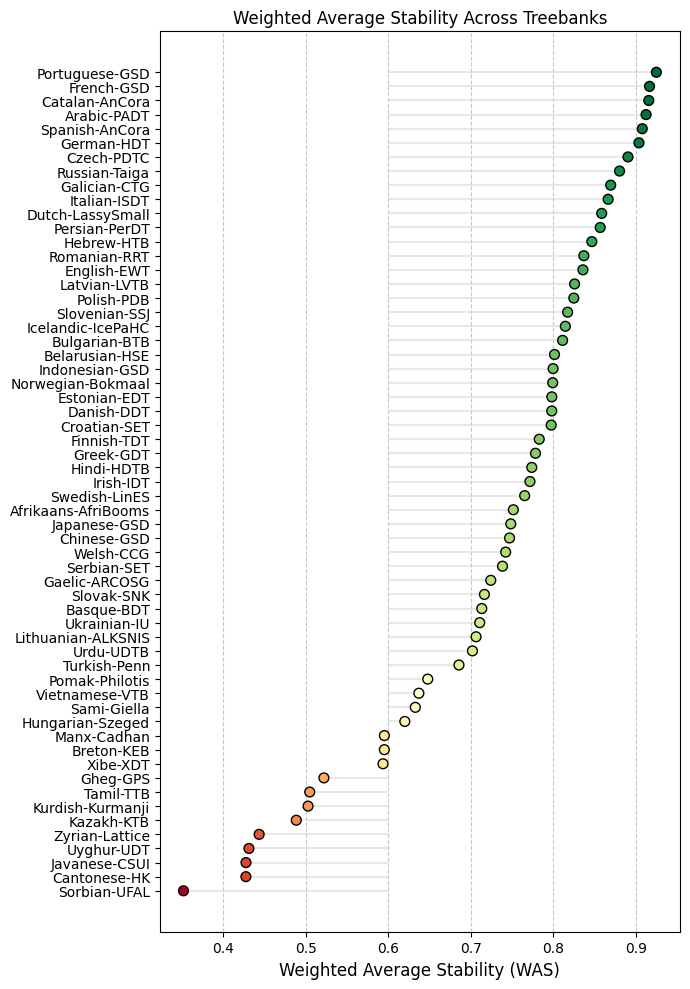

In [12]:
plt.figure(figsize=(7, 10)) # Tall and thin to accommodate 100 labels
df_sorted = df_results.sort_values('WAS')
# Use a color palette to highlight the spectrum
norm = plt.Normalize(df_sorted['WAS'].min(), df_sorted['WAS'].max())
colors = plt.cm.RdYlGn(norm(df_sorted['WAS'])) # Red (low) to Green (high)

plt.hlines(y=df_sorted['Language'], xmin=0.6, xmax=df_sorted['WAS'], color='lightgrey', alpha=0.5)
plt.scatter(df_sorted['WAS'], df_sorted['Language'], color=colors, s=50, edgecolors='black', zorder=3)

plt.title("Weighted Average Stability Across Treebanks", fontsize=12)
plt.xlabel("Weighted Average Stability (WAS)", fontsize=12)
# plt.ylabel("Language / Treebank", fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

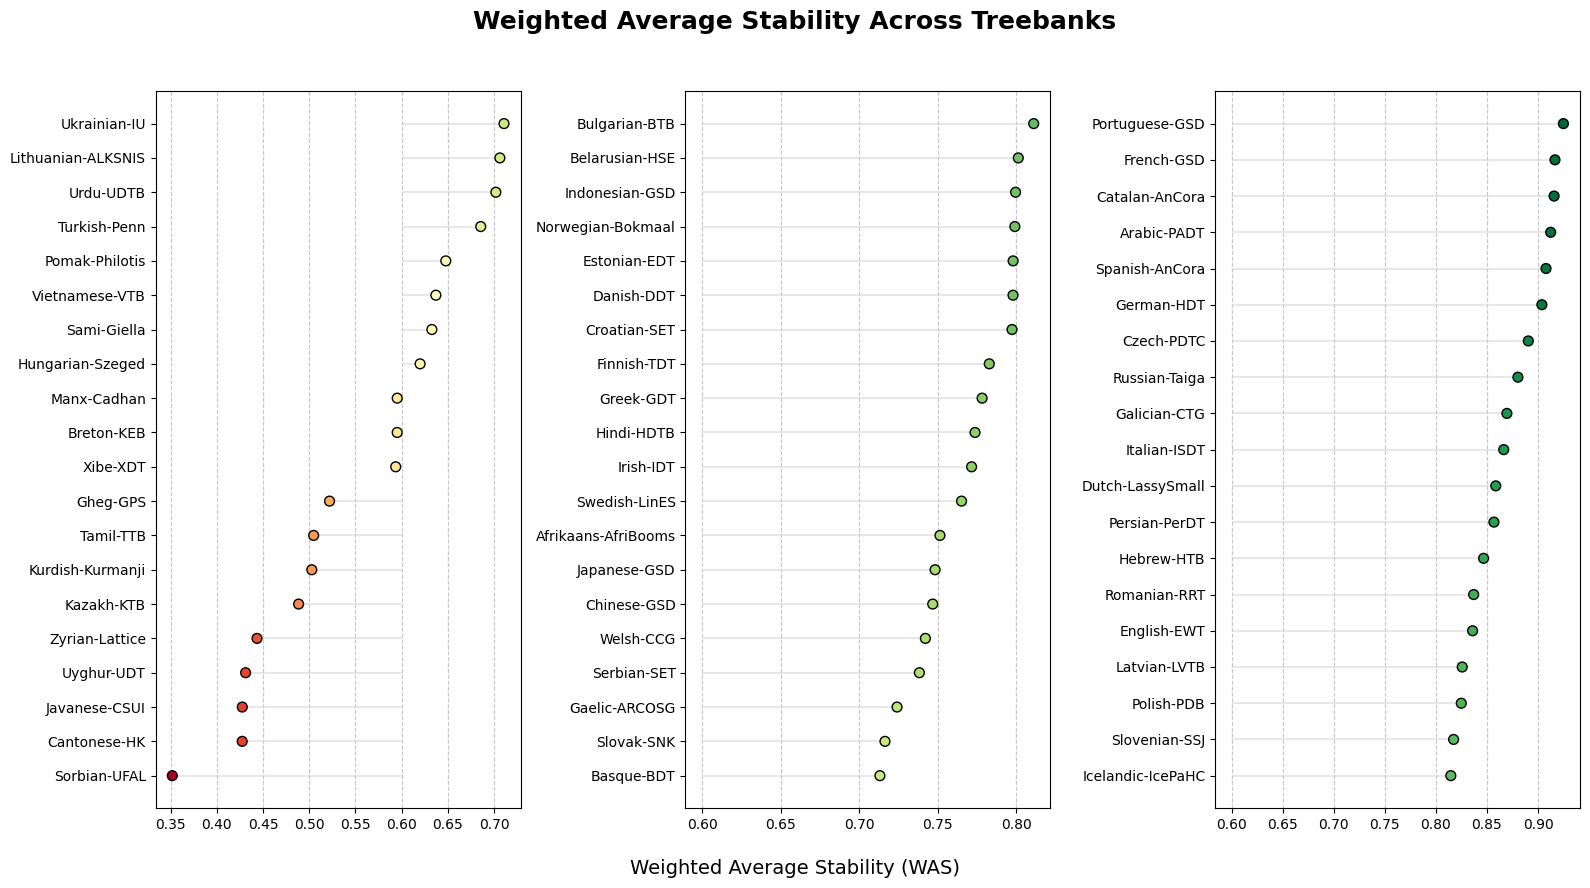

In [13]:
import matplotlib.pyplot as plt
import math

# 1. Use a standard 16:9 slide aspect ratio
fig, axes = plt.subplots(1, 3, figsize=(16, 9)) 

# 2. Keep your color normalization across the whole dataset
norm = plt.Normalize(df_sorted['WAS'].min(), df_results['WAS'].max())

# 3. Split the data into 3 equal chunks for the columns
n_cols = 3
chunk_size = math.ceil(len(df_sorted) / n_cols)

for i in range(n_cols):
    start_idx = i * chunk_size
    end_idx = min((i + 1) * chunk_size, len(df_sorted))
    chunk = df_sorted.iloc[start_idx:end_idx]
    
    ax = axes[i]
    colors = plt.cm.RdYlGn(norm(chunk['WAS']))
    
    # Plotting on the specific subplot (ax)
    ax.hlines(y=chunk['Language'], xmin=0.6, xmax=chunk['WAS'], color='lightgrey', alpha=0.5)
    ax.scatter(chunk['WAS'], chunk['Language'], color=colors, s=50, edgecolors='black', zorder=3)
    
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Optional: lock the x-axis limits so all 3 charts scale identically
    # ax.set_xlim(-0.05, 1.05) 

# 4. Global Titles and Labels
plt.suptitle("Weighted Average Stability Across Treebanks", fontsize=18, weight='bold')
fig.text(0.5, 0.02, "Weighted Average Stability (WAS)", ha='center', fontsize=14)

# Adjust layout so the suptitle and x-label don't overlap with the charts
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

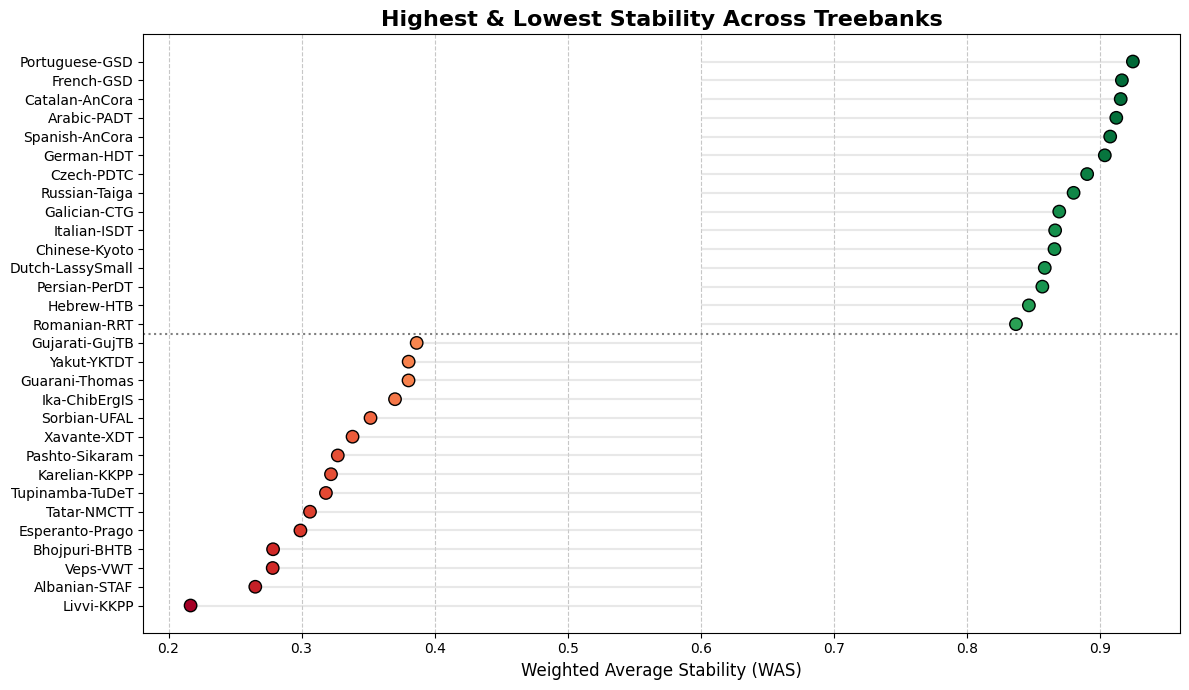

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Grab the highest and lowest performers
df_sorted = df_results.sort_values('WAS')
df_highlights = pd.concat([df_sorted.head(15), df_sorted.tail(15)])

# 2. Standard slide ratio, but not too tall
plt.figure(figsize=(12, 7)) 

norm = plt.Normalize(df_results['WAS'].min(), df_results['WAS'].max())
colors = plt.cm.RdYlGn(norm(df_highlights['WAS'])) 

plt.hlines(y=df_highlights['Language'], xmin=0.6, xmax=df_highlights['WAS'], color='lightgrey', alpha=0.5)
plt.scatter(df_highlights['WAS'], df_highlights['Language'], color=colors, s=80, edgecolors='black', zorder=3)

plt.title("Highest & Lowest Stability Across Treebanks", fontsize=16, weight='bold')
plt.xlabel("Weighted Average Stability (WAS)", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add a dashed line to separate the top and bottom clusters
plt.axhline(y=14.5, color='black', linestyle=':', alpha=0.5) 

plt.tight_layout()
plt.show()

In [32]:
stability_scores

{'Wolof-WTB': 0.7349759067514945}

In [25]:
s = full_path
lang_name_list = s.split("_")[1:][-1]
lang_name_list
# language = "_".join(lang_name_list) if len(lang_name_list) > 0 else lang_name_list
# language


'Wolof-WTB'

In [14]:
full_path = os.path.join(treebanks_folder, treebank)
full_path

'/Users/madalina/Documents/PHD/code/data/single_treebank/UD_Wolof-WTB'